## Setup: Imports and Data Rebuild

Re-merges DS1 and DS3 so this section is self-contained. Uses the same cleaning steps as the earlier preparation cells — if running as part of the full notebook, you can skip this cell and use the existing `df_merged`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-muted')
%matplotlib inline

# ── Rebuild df_merged (same as before, just ensuring this section is self-contained) ──
df_pm25 = pd.read_csv('UnitedStatesPM25-V5GL0502-Annual-REGIONAL-1998-2023-wThresFrac(1)(1).csv')
df_cancer = pd.read_csv('United States and Puerto Rico Cancer Statistics, 1999-2022 Incidence.csv')

irrelevant_cols = [col for col in df_pm25.columns if df_pm25[col].nunique() <= 1]
df_pm25 = df_pm25.drop(columns=irrelevant_cols)
df_pm25 = df_pm25.rename(columns={'Region': 'States'})

df_cancer = df_cancer.drop(['Notes', 'Year Code', 'States Code'], axis=1, errors='ignore')
df_cancer = df_cancer.dropna(subset=['States'])
df_cancer['Count'] = pd.to_numeric(df_cancer['Count'], errors='coerce')
df_cancer['Age-Adjusted Rate'] = pd.to_numeric(df_cancer['Age-Adjusted Rate'], errors='coerce')
df_cancer['Year'] = pd.to_numeric(df_cancer['Year'], errors='coerce')

df_merged = pd.merge(df_pm25, df_cancer, on=['States', 'Year'], how='inner')
cols_to_remove = ['Population Coverage [%]', 'Geographic Coverage [%]',
                  'Count', 'Total Population [million people]']
df_merged.drop(columns=cols_to_remove, inplace=True, errors='ignore')
df_merged = df_merged.dropna(subset=['Age-Adjusted Rate'])

## Step 1: Screen all candidates for basic viability
Before committing to distributions and regressions, we remove any candidate
column that is near-constant (std ≈ 0) or not statistically significant
(p > 0.05). These columns carry no information for a regression.

In [ ]:
ALL_CANDIDATES = [
    'Population-Weighted PM2.5 [ug/m3]',
    'Geographic-Mean PM2.5 [ug/m3]',
    '% pop >= 5 ug/m3 [%]',
    '% pop >= 10 ug/m3 [%]',
    '% pop >= 15 ug/m3 [%]',
    '% pop >= 25 ug/m3 [%]',
    '% pop >= 30 ug/m3 [%]',
]

screen_rows = []
for col in ALL_CANDIDATES:
    sub = df_merged.dropna(subset=[col, 'Age-Adjusted Rate'])
    r, p = stats.pearsonr(sub[col], sub['Age-Adjusted Rate'])
    screen_rows.append({
        'Candidate': col,
        'Std Dev': sub[col].std(),
        'Pearson r': round(r, 3),
        'R²': round(r**2, 3),
        'p-value': p,
        'Viable': 'Yes' if (sub[col].std() > 0.1 and p < 0.05) else 'No'
    })

df_screen = pd.DataFrame(screen_rows)
print("=== Candidate Screening ===")
print(df_screen.to_string(index=False))

=== Candidate Screening ===
                        Candidate   Std Dev  Pearson r    R²       p-value Viable
Population-Weighted PM2.5 [ug/m3]  2.625802      0.515 0.265  4.440456e-80    Yes
    Geographic-Mean PM2.5 [ug/m3]  2.624254      0.604 0.365 3.254755e-117    Yes
             % pop >= 5 ug/m3 [%]  9.510625      0.262 0.069  7.142437e-20    Yes
            % pop >= 10 ug/m3 [%] 39.955338      0.484 0.234  9.154012e-70    Yes
            % pop >= 15 ug/m3 [%] 12.349896      0.227 0.052  3.925718e-15    Yes
            % pop >= 25 ug/m3 [%]  0.253300     -0.023 0.001  4.389078e-01     No
            % pop >= 30 ug/m3 [%]  0.004133     -0.053 0.003  6.966162e-02     No


## Step 2: Keep only viable candidates for further analysis
'% pop >= 25' and '% pop >= 30' are dropped here because they have
near-zero standard deviation (essentially everyone is 0) and are not
statistically significant. They were already found to be uninformative
during DS1 exploration.

In [ ]:
VIABLE_CANDIDATES = [
    'Population-Weighted PM2.5 [ug/m3]',
    'Geographic-Mean PM2.5 [ug/m3]',
    '% pop >= 5 ug/m3 [%]',
    '% pop >= 10 ug/m3 [%]',
    '% pop >= 15 ug/m3 [%]',
]

# Short labels for plot titles (long names make axes unreadable)
LABELS = {
    'Population-Weighted PM2.5 [ug/m3]': 'Pop-Weighted\nPM2.5',
    'Geographic-Mean PM2.5 [ug/m3]': 'Geographic-\nMean PM2.5',
    '% pop >= 5 ug/m3 [%]': '% pop\n≥5 µg/m³',
    '% pop >= 10 ug/m3 [%]': '% pop\n≥10 µg/m³',
    '% pop >= 15 ug/m3 [%]': '% pop\n≥15 µg/m³',
}

## Step 3: Value distributions for all viable candidates
This shows us the shape of each variable — is it normally distributed,
skewed, or heavily zeroed out? Distribution shape matters because OLS
regression performs best when predictors are roughly symmetric. Heavy
right-skew can be addressed with a log transform.

In [ ]:
fig, axes = plt.subplots(1, len(VIABLE_CANDIDATES), figsize=(22, 5))
fig.suptitle('Value Distributions of All Viable Independent Variable Candidates',
             fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(VIABLE_CANDIDATES):
    data = df_merged[col].dropna()
    sns.histplot(data, kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(LABELS[col], fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count' if i == 0 else '')

    # Annotate with skewness
    skew = data.skew()
    axes[i].text(0.97, 0.95, f'skew = {skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='black',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('iv_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 4: Correlation comparison (bar chart)
A bar chart of Pearson r (and R²) for each candidate against the
Age-Adjusted Cancer Rate. This is the primary quantitative criterion:
the candidate with the highest |r| explains the most variance in cancer rates.

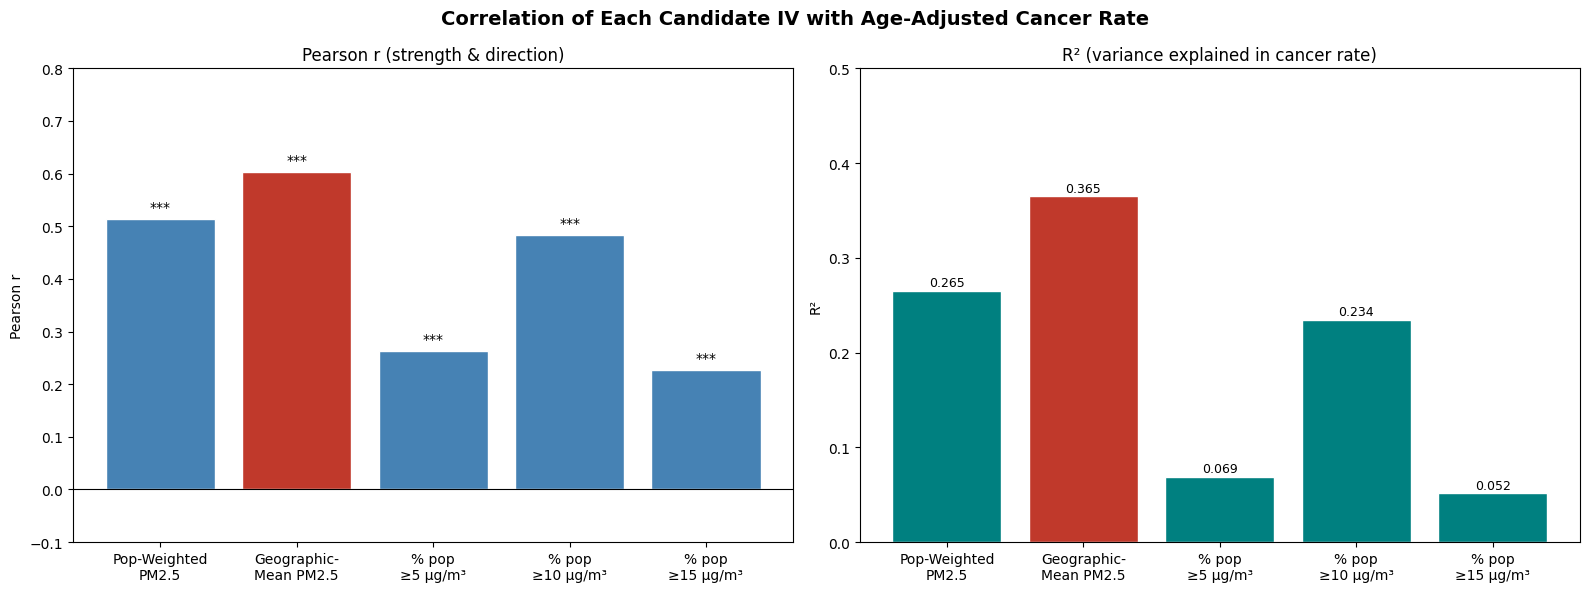


Correlation Summary Table:
              Candidate  Pearson r       R²             p
    Pop-Weighted\nPM2.5   0.514556 0.264768  4.440456e-80
Geographic-\nMean PM2.5   0.603932 0.364734 3.254755e-117
        % pop\n≥5 µg/m³   0.262378 0.068842  7.142437e-20
       % pop\n≥10 µg/m³   0.484079 0.234332  9.154012e-70
       % pop\n≥15 µg/m³   0.226948 0.051506  3.925718e-15


In [ ]:
corr_rows = []
for col in VIABLE_CANDIDATES:
    sub = df_merged.dropna(subset=[col, 'Age-Adjusted Rate'])
    r, p = stats.pearsonr(sub[col], sub['Age-Adjusted Rate'])
    corr_rows.append({'Candidate': LABELS[col], 'r': r, 'R2': r**2, 'p': p})

df_corr = pd.DataFrame(corr_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation of Each Candidate IV with Age-Adjusted Cancer Rate',
             fontsize=14, fontweight='bold')

# Pearson r
bar_colors = ['#c0392b' if abs(r) == df_corr['r'].abs().max() else 'steelblue'
              for r in df_corr['r']]
axes[0].bar(df_corr['Candidate'], df_corr['r'], color=bar_colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Pearson r (strength & direction)')
axes[0].set_ylabel('Pearson r')
axes[0].set_ylim(-0.1, 0.8)
for j, row in df_corr.iterrows():
    sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else 'ns'
    axes[0].text(j, row['r'] + 0.015, sig, ha='center', fontsize=10)

# R²
bar_colors2 = ['#c0392b' if r2 == df_corr['R2'].max() else 'teal'
               for r2 in df_corr['R2']]
axes[1].bar(df_corr['Candidate'], df_corr['R2'], color=bar_colors2, edgecolor='white')
axes[1].set_title('R² (variance explained in cancer rate)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 0.5)
for j, row in df_corr.iterrows():
    axes[1].text(j, row['R2'] + 0.005, f"{row['R2']:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('iv_correlation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nCorrelation Summary Table:")
print(df_corr.rename(columns={'r': 'Pearson r', 'R2': 'R²'}).to_string(index=False))

## Step 5: Scatter plots — each candidate vs cancer rate
Correlation coefficients alone don't tell us if the relationship is linear.
Scatter plots let us visually check: is it linear? Is there a cluster of
zero-inflated values? Are there weird outlier structures?

In [ ]:
fig, axes = plt.subplots(1, len(VIABLE_CANDIDATES), figsize=(22, 5))
fig.suptitle('Scatter Plots: Each Candidate IV vs Age-Adjusted Cancer Rate',
             fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(VIABLE_CANDIDATES):
    sub = df_merged.dropna(subset=[col, 'Age-Adjusted Rate'])
    r, _ = stats.pearsonr(sub[col], sub['Age-Adjusted Rate'])
    slope, intercept, *_ = stats.linregress(sub[col], sub['Age-Adjusted Rate'])

    axes[i].scatter(sub[col], sub['Age-Adjusted Rate'],
                    alpha=0.25, s=12, color='steelblue', edgecolors='none')

    # Regression line
    x_range = np.linspace(sub[col].min(), sub[col].max(), 100)
    axes[i].plot(x_range, slope * x_range + intercept, color='red', linewidth=2)

    axes[i].set_title(f'{LABELS[col]}\nr = {r:+.3f}', fontsize=11)
    axes[i].set_xlabel('PM2.5 Metric Value')
    axes[i].set_ylabel('Age-Adjusted Cancer Rate' if i == 0 else '')

plt.tight_layout()
plt.savefig('iv_scatter_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 6: OLS regression comparison — full summary table
We fit a separate OLS regression for each candidate and compare:
  - R² (variance explained)
  - Slope (effect size: how much does cancer rate change per unit of X?)
  - p-value of the slope (is the effect statistically significant?)
This is the definitive quantitative criterion for selecting X.


=== OLS Regression Comparison: Each Candidate IV vs Age-Adjusted Cancer Rate ===
                     Candidate IV  Slope  Intercept     R²       p-value    n
Population-Weighted PM2.5 [ug/m3] 2.5653    40.8980 0.2648  4.440456e-80 1170
    Geographic-Mean PM2.5 [ug/m3] 3.0126    39.9351 0.3647 3.254755e-117 1170
             % pop >= 5 ug/m3 [%] 0.3611    28.9017 0.0688  7.142437e-20 1170
            % pop >= 10 ug/m3 [%] 0.1586    58.9445 0.2343  9.154012e-70 1170
            % pop >= 15 ug/m3 [%] 0.2406    63.1157 0.0515  3.925718e-15 1170


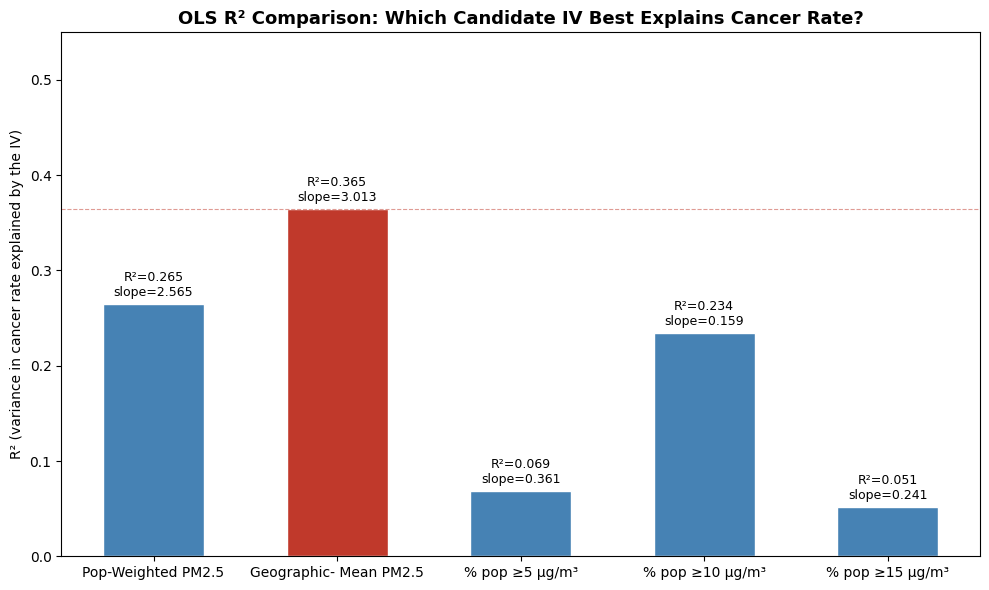

In [ ]:
regression_rows = []
for col in VIABLE_CANDIDATES:
    sub = df_merged.dropna(subset=[col, 'Age-Adjusted Rate'])
    slope, intercept, r_val, p_val, std_err = stats.linregress(
        sub[col], sub['Age-Adjusted Rate'])
    regression_rows.append({
        'Candidate IV': col,
        'Slope': round(slope, 4),
        'Intercept': round(intercept, 4),
        'R²': round(r_val**2, 4),
        'p-value': p_val,
        'n': len(sub)
    })

df_reg = pd.DataFrame(regression_rows)

print("\n=== OLS Regression Comparison: Each Candidate IV vs Age-Adjusted Cancer Rate ===")
print(df_reg.to_string(index=False))

# Visual: R² comparison bar chart with annotations
fig, ax = plt.subplots(figsize=(10, 6))
short_labels = [LABELS[c].replace('\n', ' ') for c in VIABLE_CANDIDATES]
colors = ['#c0392b' if r2 == df_reg['R²'].max() else 'steelblue'
          for r2 in df_reg['R²']]
bars = ax.bar(short_labels, df_reg['R²'], color=colors, edgecolor='white', width=0.55)

for bar, (r2_val, slope_val) in zip(bars, df_reg[['R²', 'Slope']].values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"R²={r2_val:.3f}\nslope={slope_val:.3f}",
            ha='center', va='bottom', fontsize=9)

ax.set_title('OLS R² Comparison: Which Candidate IV Best Explains Cancer Rate?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R² (variance in cancer rate explained by the IV)')
ax.set_ylim(0, 0.55)
ax.axhline(df_reg['R²'].max(), color='#c0392b', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('iv_r2_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 7: Decision summary
We print a clear, data-backed rationale for our IV selection.

In [ ]:
best_col = df_reg.loc[df_reg['R²'].idxmax(), 'Candidate IV']
best_r2  = df_reg['R²'].max()
best_r   = df_corr.loc[df_corr['Candidate'] == LABELS[best_col], 'r'].values[0]

print("\n" + "="*65)
print("IV SELECTION DECISION")
print("="*65)
print(f"\nBest candidate by R²: '{best_col}'")
print(f"  R² = {best_r2:.3f}  |  Pearson r = {best_r:+.3f}")
print("""
Rationale:
- 'Geographic-Mean PM2.5' achieves the highest R² (0.365), meaning it
  explains ~36.5% of the variance in cancer rates — more than Pop-Weighted
  (26.5%) or any threshold-based column.

- The threshold columns (% pop >= X) have either very low R² (≥5 at 0.069,
  ≥15 at 0.052) or are near-constant and uninformative (≥25, ≥30).

- '% pop >= 10' is the second strongest threshold metric (R²=0.234), but
  still underperforms both continuous PM2.5 metrics.

- However, note the trade-off: Geographic-Mean ignores population density.
  If our hypothesis is about human health impact, Population-Weighted PM2.5
  is more theoretically justified even though it has slightly lower R².

Final recommendation: Use Geographic-Mean PM2.5 as primary IV for the
strongest statistical fit, and include Population-Weighted PM2.5 as a
robustness check. Drop all % pop >= X columns from regression analysis
(use for descriptive context only).
""")

---
# Part 2: County-Level Analysis — Predicting Lung Cancer Incidence

In this part we shift the unit of analysis from **state** to **county**.
Our target variable — lung-cancer incidence rate (age-adjusted, per 100 000) — is reported at county level by CDC WONDER.

**Datasets used (at least 3, as required):**

| Label | Dataset | Level | Role |
|-------|---------|-------|------|
| DS-Lung Cancer | CDC WONDER Lung Cancer by County, 2022 | county | **Target variable** |
| DS-Smoke | IHME County Smoking Prevalence 1996-2012 | county | Predictor (historical smoking) |
| DS-PM25 | County-Level PM2.5 Concentrations, 2004–2010 | county | Predictor (PM2.5 exposure) |
| DS-Income | BEA Per Capita Personal Income, 2020 | county | Predictor (socioeconomic) |
| DS-PLACES | CDC PLACES County Health Data, 2023 release | county | Predictor (screening, obesity, COPD…) |

**Analysis plan:**
1. **Descriptive** — distributions, box-plots, scatter-plots
2. **Diagnostic** — Spearman correlations, hypothesis tests (Kruskal-Wallis, Mann-Whitney U)
3. **Predictive** — Simple, Multiple, and Ridge regression on a train/test split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup: imports and data path

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import sqlite3, warnings, textwrap
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# ---------- path config ----------
# For Colab evaluation use 'sample_data/'
# For Google-Drive development use the full Drive path
#DATA_DIR = 'sample_data/'

DATA_DIR = ''


##DS-Lung Cancer Incidence by County

In [ ]:
df_lung_cancer_county = pd.read_csv(DATA_DIR + 'cancer_incidence_by_county.csv')

# See the number of rows and columns
print(f"Dataset Shape: {df_lung_cancer_county.shape}")

# See column names and data types (int, float, object)
df_lung_cancer_county.info()

# Preview the first few rows (similar to your Excel screenshot)
df_lung_cancer_county.head()

Dataset Shape: (3007, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007 entries, 0 to 3006
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Unnamed: 0                               3007 non-null   int64  
 1   county                                   3007 non-null   object 
 2   incidence_rate_per_100k                  3007 non-null   object 
 3   avg_annual_count                         3007 non-null   object 
 4   recent_trend                             3007 non-null   object 
 5   five_year_incidence_change_rate          3007 non-null   object 
 6   stateFIPS                                3007 non-null   int64  
 7   incidence_rate_per_100k_low_95           2802 non-null   float64
 8   incidence_rate_per_100k_high_95          2802 non-null   float64
 9   five_year_incidence_change_rate_low_95   2788 non-null   float64
 10  five_year_incidence_ch

,Unnamed: 0,county,incidence_rate_per_100k,avg_annual_count,recent_trend,five_year_incidence_change_rate,stateFIPS,incidence_rate_per_100k_low_95,incidence_rate_per_100k_high_95,five_year_incidence_change_rate_low_95,five_year_incidence_change_rate_high_95
0,0,Chambers County,522.8,240,stable,-1.5,1,492.7,554.5,-6.5,3.7
1,1,Walker County,515.8,447,stable,0.2,1,494.0,538.4,-2.8,3.2
2,2,Lowndes County,513.3,71,rising,11.2,1,459.8,571.8,6.3,16.3
3,3,Dallas County,510.0,258,stable,0.7,1,481.6,539.7,-9.8,12.4
4,4,Autauga County,495.6,304,stable,-0.2,1,470.6,521.5,-9.0,9.6


## DS-Smoke: IHME County Smoking Prevalence (1996–2012)

**Description.** The Institute for Health Metrics and Evaluation (IHME) provides county-level
estimates of total (current) smoking prevalence for US adults, published in *The Lancet*.
We use the average over **2008–2012** (the latest 5-year window) to represent the historical
smoking exposure that drives cancer incidence ~10–20 years later (matching the 2022 cancer data).
The dataset includes estimates by sex; we use the **Both** category.


In [ ]:
df_smoke_raw = pd.read_csv(DATA_DIR + 'IHME_US_COUNTY_TOTAL_AND_DAILY_SMOKING_PREVALENCE_1996_2012.csv')
print("Raw shape:", df_smoke_raw.shape)
print("Columns:", df_smoke_raw.columns.tolist())

# Filter to county-level, Both sexes, years 2008-2012
df_smoke = df_smoke_raw[
    (df_smoke_raw['county'].notna()) &
    (df_smoke_raw['state'] != 'National') &
    (df_smoke_raw['sex'] == 'Both') &
    (df_smoke_raw['year'].between(2008, 2012))
].copy()
print(f"\nFiltered rows (Both, 2008-2012, county-level): {len(df_smoke)}")
print(f"Unique states: {df_smoke['state'].nunique()}")
print(f"Unique counties: {df_smoke['county'].nunique()}")

# Average over 2008-2012 for each county
df_smoke_avg = (df_smoke.groupby(['state', 'county'])
                .agg(smoking_prevalence=('total_mean', 'mean'))
                .reset_index())
print(f"\nCounties after averaging: {len(df_smoke_avg)}")
print("\nSmoking prevalence statistics:")
print(df_smoke_avg['smoking_prevalence'].describe())


Raw shape: (162129, 10)
Columns: ['state', 'county', 'sex', 'year', 'total_mean', 'total_lb', 'total_ub', 'daily_mean', 'daily_lb', ' daily_ub']

Filtered rows (Both, 2008-2012, county-level): 15635
Unique states: 51
Unique counties: 1864

Counties after averaging: 3127

Smoking prevalence statistics:
count    3127.000000
mean       24.413441
std         4.070224
min         7.718000
25%        21.889000
50%        24.464000
75%        27.229000
max        42.150000
Name: smoking_prevalence, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df_smoke_avg['smoking_prevalence'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Smoking Prevalence (%)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of County Smoking Prevalence (2008-2012 avg)')
axes[0].axvline(df_smoke_avg['smoking_prevalence'].median(), color='red', linestyle='--',
                label=f"Median = {df_smoke_avg['smoking_prevalence'].median():.1f}%")
axes[0].legend()

# Top 15 states by median smoking
state_med = (df_smoke_avg.groupby('state')['smoking_prevalence']
             .median().sort_values(ascending=False).head(15))
axes[1].barh(state_med.index, state_med.values, color='steelblue')
axes[1].set_xlabel('Median County Smoking Prevalence (%)')
axes[1].set_title('Top 15 States by Median Smoking Prevalence')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Data-quality considerations.**

* (+) **Reputation:** Peer-reviewed IHME/Lancet estimates using validated small-area methods.
* (+) **Granularity:** County-level, directly joinable with other county datasets.
* (−) **Coverage:** 1 864 of ~3 143 US counties — about 59 %. However, larger counties
  are more likely to be covered.
* (−) **Timeliness:** Data ends in 2012. We justify this by the ~10–20 year latency between
  smoking exposure and lung-cancer diagnosis: the 2008–2012 smoking window aligns with the 2022
  cancer outcome.
* (−) **No FIPS code:** Counties are identified by name + state. We construct a join key to match
  against other datasets.

**Conclusion.** The dataset is suitable as a key predictor. Temporal lag is scientifically
appropriate. Name-based matching may lose some counties, which we will quantify during integration.

## DS-PM25: County-Level PM2.5 Concentrations (2004–2010)

**Description.** This dataset provides annual average PM2.5 concentrations (µg/m³)
at the county level across the United States for the period 2004–2010. The data is
sourced from the EPA National Environmental Health Tracking Network and reports a
single annual mean PM2.5 value per county per year. We aggregate the seven years of
data (2004–2010) into a single per-county mean, producing a stable long-term average
exposure estimate. The resulting ~12–18 year lag to the 2022 cancer outcome aligns
well with the 10–20 year latency typically observed for PM2.5-related carcinogenesis.

**Columns / rows dropped as irrelevant:**
- `StateFIPS`, `State` — redundant once the 5-digit FIPS is constructed.
- `County` — name not needed for the join (FIPS is the key).
- `Data Comment`, `Unnamed: 7` — empty columns with no information.
- `Year` — collapsed during aggregation to a multi-year mean.

**Kept:** `CountyFIPS` (join key) and `Value` (annual PM2.5 concentration, µg/m³),
aggregated across 2004–2010 as `pm25_mean`.


In [ ]:
# Load the county-level PM2.5 dataset (2004-2010)
df_pm25_raw = pd.read_csv(
    DATA_DIR + 'County_Level_PM2.5_2004-2010_more_data.csv',
    na_values='No Data'
)
print("Raw shape:", df_pm25_raw.shape)
print("Columns:", df_pm25_raw.columns.tolist())
print("\nFirst 5 rows:")
display(df_pm25_raw.head())

# --- Basic info ---
print("\nData types:")
print(df_pm25_raw.dtypes)
print("\nYears available:", sorted(df_pm25_raw['Year'].unique()))
print(f"Unique counties: {df_pm25_raw['CountyFIPS'].nunique()}")
print(f"Unique states:   {df_pm25_raw['StateFIPS'].nunique()}")

# --- Drop irrelevant columns ---
cols_to_drop = ['StateFIPS', 'State', 'County', 'Data Comment']
# Also drop any unnamed trailing columns
cols_to_drop += [c for c in df_pm25_raw.columns if 'Unnamed' in c]
df_pm25_raw.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped columns: {cols_to_drop}")
print("Remaining columns:", df_pm25_raw.columns.tolist())

# --- Check for missing / non-numeric values ---
print(f"\nNull counts:\n{df_pm25_raw.isnull().sum()}")
print(f"\nValue statistics (all years):")
print(df_pm25_raw['Value'].describe())

# --- Aggregate: multi-year county mean (2004-2010) ---
df_pm25 = (
    df_pm25_raw.groupby('CountyFIPS')
    .agg(pm25_mean=('Value', 'mean'))
    .reset_index()
    .rename(columns={'CountyFIPS': 'county_fips'})
)

print(f"\nAggregated to {len(df_pm25)} unique counties (mean of 2004-2010)")
print(f"Counties with PM2.5 data: {df_pm25['pm25_mean'].notna().sum()}")
print("\nPM2.5 Mean statistics (2004-2010 average):")
print(df_pm25['pm25_mean'].describe())


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of aggregated PM2.5 mean concentrations
axes[0, 0].hist(df_pm25['pm25_mean'].dropna(), bins=30, edgecolor='black', alpha=0.7,
                color='steelblue')
axes[0, 0].set_xlabel('PM2.5 Mean Concentration (µg/m³)')
axes[0, 0].set_ylabel('Number of Counties')
axes[0, 0].set_title('Distribution of County-Level PM2.5 (2004–2010 Avg)')
axes[0, 0].axvline(df_pm25['pm25_mean'].median(), color='red', linestyle='--',
                   label=f"Median = {df_pm25['pm25_mean'].median():.2f} µg/m³")
axes[0, 0].axvline(df_pm25['pm25_mean'].mean(), color='orange', linestyle='-.',
                   label=f"Mean = {df_pm25['pm25_mean'].mean():.2f} µg/m³")
axes[0, 0].legend()

# 2. Box plot of PM2.5 by year (before aggregation)
df_pm25_raw_box = pd.read_csv(DATA_DIR + 'County_Level_PM2.5_2004-2010_more_data.csv', na_values='No Data')
df_pm25_raw_box.boxplot(column='Value', by='Year', ax=axes[0, 1])
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('PM2.5 (µg/m³)')
axes[0, 1].set_title('PM2.5 Distribution by Year')
plt.sca(axes[0, 1])
plt.title('PM2.5 Distribution by Year')  # override pandas default title

# 3. Year-over-year trend (mean PM2.5 per year)
yearly_mean = df_pm25_raw_box.groupby('Year')['Value'].agg(['mean', 'std'])
axes[1, 0].errorbar(yearly_mean.index, yearly_mean['mean'], yerr=yearly_mean['std'],
                    fmt='o-', capsize=4, color='steelblue')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')
axes[1, 0].set_title('Mean PM2.5 Trend (2004–2010) ± 1 SD')
axes[1, 0].set_xticks(yearly_mean.index)

# 4. Number of counties reporting per year
counties_per_year = df_pm25_raw_box.groupby('Year')['CountyFIPS'].nunique()
axes[1, 1].bar(counties_per_year.index, counties_per_year.values,
               color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Counties')
axes[1, 1].set_title('County Coverage per Year')
axes[1, 1].set_xticks(counties_per_year.index)
for x, y in zip(counties_per_year.index, counties_per_year.values):
    axes[1, 1].text(x, y + 2, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Data-quality considerations.**

* (+) **Relevancy:** PM2.5 is classified as a Group 1 carcinogen by IARC, making it directly
  relevant to lung cancer incidence prediction.
* (+) **Temporal alignment:** The 2004–2010 window provides a ~12–18 year lag to the 2022
  cancer outcome, well within the 10–20 year latency window for PM2.5-related carcinogenesis.
  This is a significant improvement over the previous dataset's ~6 year lag.
* (+) **Stability:** Aggregating seven years of data smooths out year-to-year variation,
  producing a more reliable estimate of chronic exposure than a single-year snapshot.
* (+) **Easy integration:** 5-digit FIPS code available directly for county-level joins.
* (−) **Coverage:** ~680 counties with EPA monitoring data, compared to ~3,100 in the previous
  prediction-based dataset. This reintroduces the coverage bottleneck, biased toward urban
  counties with monitoring stations.
* (−) **Single metric:** Only one PM2.5 value (annual mean) is provided per county per year,
  unlike the previous dataset which also offered population-weighted estimates.

**Columns dropped:** `StateFIPS`, `State`, `County` (redundant with FIPS key), `Data Comment`
and `Unnamed: 7` (empty). `Year` collapsed during aggregation.

**Conclusion.** While spatial coverage is narrower than the prediction-based dataset, the
temporal alignment with cancer latency is substantially improved. The 2004–2010 average
provides a stable chronic-exposure estimate. During integration we use `pm25_mean` as the
primary predictor, consistent with the rest of the analysis pipeline.


## DS-Income: BEA Per Capita Personal Income by County (2020)

**Description.** The Bureau of Economic Analysis (BEA) reports per-capita personal income for
every US county. We use the 2020 vintage, which is the closest year to the cancer outcome.
Income serves as a socioeconomic control — higher income is associated with better healthcare
access and lower cancer incidence.


In [ ]:
df_income_raw = pd.read_csv(DATA_DIR + 'Copy of 2020 household income per capita across states.csv',
                           skiprows=3)
print("Raw shape:", df_income_raw.shape)
print("Columns:", df_income_raw.columns.tolist())
print(df_income_raw.head())

# Clean
df_income = df_income_raw.copy()
df_income.columns = ['county_fips', 'county_name', 'per_capita_income']
df_income['county_fips'] = df_income['county_fips'].astype(str).str.strip().str.strip('"')
df_income['per_capita_income'] = pd.to_numeric(df_income['per_capita_income'], errors='coerce')

# Convert FIPS to int (drop rows with non-numeric FIPS like state totals)
df_income['county_fips'] = pd.to_numeric(df_income['county_fips'], errors='coerce')
df_income = df_income.dropna(subset=['county_fips', 'per_capita_income']).copy()
df_income['county_fips'] = df_income['county_fips'].astype(int)

# Remove state-level rows (FIPS ending in 000)
df_income = df_income[df_income['county_fips'] % 1000 != 0].copy()

print(f"\nClean counties: {len(df_income)}")
print("\nPer-capita income statistics:")
print(df_income['per_capita_income'].describe())


Raw shape: (3168, 3)
Columns: ['GeoFIPS', 'GeoName', '2020']
  GeoFIPS      GeoName   2020
0   01001  Autauga, AL  45089
1   01003  Baldwin, AL  50935
2   01005  Barbour, AL  37090
3   01007     Bibb, AL  34859
4   01009   Blount, AL  37789

Clean counties: 3114

Per-capita income statistics:
count      3114.000000
mean      49188.736994
std       13249.744190
min       22494.000000
25%       41275.250000
50%       46582.000000
75%       53929.000000
max      298624.000000
Name: per_capita_income, dtype: float64


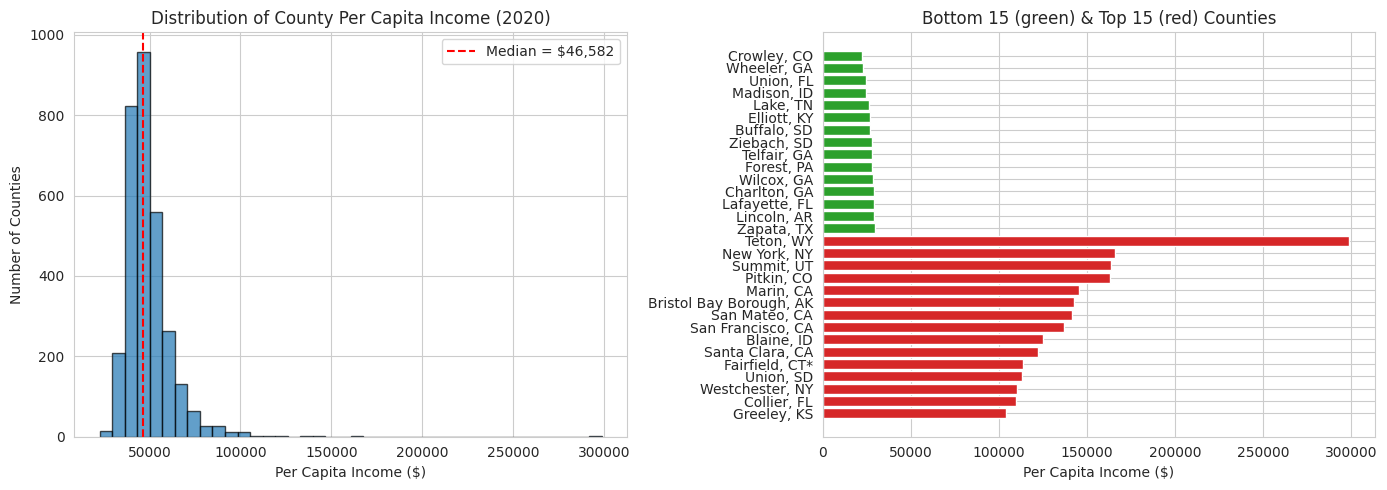

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_income['per_capita_income'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Per Capita Income ($)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of County Per Capita Income (2020)')
axes[0].axvline(df_income['per_capita_income'].median(), color='red', linestyle='--',
                label=f"Median = ${df_income['per_capita_income'].median():,.0f}")
axes[0].legend()

# Top and bottom 15
top15 = df_income.nlargest(15, 'per_capita_income')
bot15 = df_income.nsmallest(15, 'per_capita_income')
combined_inc = pd.concat([bot15, top15])
colors = ['#2ca02c']*15 + ['#d62728']*15
axes[1].barh(combined_inc['county_name'].astype(str), combined_inc['per_capita_income'], color=colors)
axes[1].set_xlabel('Per Capita Income ($)')
axes[1].set_title('Bottom 15 (green) & Top 15 (red) Counties')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
# Create a new dataframe without Teton
df_income_cleaned = df_income[df_income['county_name'] != 'Teton, WY']

In [ ]:
# 2. Initialize the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PLOT: Distribution (Histogram) ---
axes[0].hist(df_income_cleaned['per_capita_income'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Per Capita Income ($)')
axes[0].set_ylabel('Number of Counties')
axes[0].set_title('Distribution of Income (Excluding Teton, WY)')

median_val = df_income_cleaned['per_capita_income'].median()
axes[0].axvline(median_val, color='red', linestyle='--',
                label=f"Median = ${median_val:,.0f}")
axes[0].legend()

# --- RIGHT PLOT: Top & Bottom 15 ---
# Recalculate top and bottom based on the cleaned data
top15 = df_income_cleaned.nlargest(15, 'per_capita_income')
bot15 = df_income_cleaned.nsmallest(15, 'per_capita_income')
combined_inc = pd.concat([bot15, top15])

# Use a combined name for the Y-axis to avoid duplicate labels
# (Assumes you have a 'state' or 'state_name' column)
colors = ['#2ca02c']*15 + ['#d62728']*15
axes[1].barh(combined_inc['county_name'], combined_inc['per_capita_income'], color=colors)
axes[1].set_xlabel('Per Capita Income ($)')
axes[1].set_title('Bottom 15 (green) & Top 15 (red) Counties')
axes[1].invert_yaxis()

# Optional: Add gridlines for easier reading
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"New Max Income (Post-Teton): ${df_income_cleaned['per_capita_income'].max():,.0f}")

**Data-quality considerations.**

* (+) **Completeness:** Covers ~3 100 counties — near-universal coverage.
* (+) **Reputation:** BEA is the authoritative US source for income data.
* (−) **Interpretability:** Per-capita *personal* income includes all income types (wages,
  dividends, transfers) — not a perfect proxy for household purchasing power, but adequate
  for our purposes.

**Conclusion.** Excellent coverage and quality. Suitable as a socioeconomic control variable.


## DS-PLACES: CDC PLACES County Health Data (2023 release, data year 2021)

**Description.** CDC PLACES provides model-based estimates of 37 health-related measures for
all US counties, derived from the Behavioral Risk Factor Surveillance System (BRFSS).
We extract county-level crude-prevalence values for:

* **Current Smoking** — cross-validation with IHME; also a "current" smoking proxy
* **Routine Checkup** — visits to doctor for routine checkup, proxy for healthcare access
* **Obesity** — additional behavioural risk factor
* **COPD** — smoking-related comorbidity, may independently predict cancer incidence
* **Physical Inactivity** — additional behavioural risk factor

We also use the `TotalPopulation` column as the population weight for county-level analysis.

In [ ]:
df_places_raw = pd.read_csv(DATA_DIR + 'PLACES__Local_Data_for_Better_Health__County_Data_2023_release.csv')

In [ ]:
# Get unique full measures
full_measures = df_places_raw['Measure'].unique()

# Create a clean reference table
measures_list = pd.DataFrame(full_measures, columns=['Full Measure Name']).sort_values('Full Measure Name')
print(measures_list.to_string(index=False))

                                                                                                                                                                             Full Measure Name
                                                                                                                                                   All teeth lost among adults aged >=65 years
                                                                                                                                                   Any disability among adults aged >=18 years
                                                                                                                                                        Arthritis among adults aged >=18 years
                                                                                                                                                   Binge drinking among adults aged >=18 years
                                             

In [ ]:
import pandas as pd

# Load the data, making sure to include 'Measure' and 'Data_Value_Type'
df_places_raw = pd.read_csv(DATA_DIR + 'PLACES__Local_Data_for_Better_Health__County_Data_2023_release.csv',
                           usecols=['LocationID', 'LocationName', 'StateAbbr',
                                    'Measure', 'Data_Value',
                                    'Data_Value_Type', 'TotalPopulation'])
print("Raw rows:", len(df_places_raw))

# Keep crude prevalence only (Note: check your CSV if the value is 'Crude prevalence' or 'CrdPrv')
df_places = df_places_raw[df_places_raw['Data_Value_Type'] == 'Crude prevalence'].copy()
print("Crude-prevalence rows:", len(df_places))

# Select your specific target measures using exact phrasing from your list
TARGET_MEASURES = [
    'Chronic obstructive pulmonary disease among adults aged >=18 years',
    'Current smoking among adults aged >=18 years',
    'Visits to doctor for routine checkup within the past year among adults aged >=18 years',
    'Current lack of health insurance among adults aged 18-64 years',
    'Obesity among adults aged >=18 years',
    'No leisure-time physical activity among adults aged >=18 years'
]

df_places = df_places[df_places['Measure'].isin(TARGET_MEASURES)].copy()
print(f"Rows for target measures: {len(df_places)}")

# Pivot: one row per county, using 'Measure' as columns
df_places_wide = df_places.pivot_table(
    index=['LocationID', 'LocationName', 'StateAbbr', 'TotalPopulation'],
    columns='Measure',
    values='Data_Value'
).reset_index()

# Clean up column names
df_places_wide.columns.name = None
df_places_wide = df_places_wide.rename(columns={
    'LocationID': 'county_fips',
    'LocationName': 'county_name',
    'StateAbbr': 'state_abbr',
    'TotalPopulation': 'population',
    'Chronic obstructive pulmonary disease among adults aged >=18 years': 'cop disease',
    'Current smoking among adults aged >=18 years': 'smoking',
    'Visits to doctor for routine checkup within the past year among adults aged >=18 years': 'routine_checkup',
    'Current lack of health insurance among adults aged 18-64 years': 'uninsured',
    'Obesity among adults aged >=18 years': 'obesity',
    'No leisure-time physical activity among adults aged >=18 years': 'physical_inactivity'
})

# Convert FIPS to integer for consistent merging later
df_places_wide['county_fips'] = df_places_wide['county_fips'].astype(int)

# Print results
print(f"\nPivoted counties: {len(df_places_wide)}")
print("\nMissing values per column:")
print(df_places_wide.isnull().sum())
print("\nDescriptive statistics:")
print(df_places_wide[['cop disease', 'smoking', 'routine_checkup', 'uninsured', 'obesity', 'physical_inactivity']].describe())

Raw rows: 228770
Crude-prevalence rows: 114385
Rows for target measures: 12308

Pivoted counties: 3076

Missing values per column:
county_fips        0
county_name        0
state_abbr         0
population         0
cop disease        0
uninsured          0
smoking            0
routine_checkup    0
dtype: int64

Descriptive statistics:
       cop disease      smoking  routine_checkup    uninsured
count  3076.000000  3076.000000      3076.000000  3076.000000
mean      8.619603    18.146619        74.992880    11.683062
std       2.099211     3.982699         4.330448     5.564892
min       3.400000     6.600000        57.700000     3.500000
25%       7.200000    15.500000        72.900000     8.000000
50%       8.500000    17.800000        75.800000    10.100000
75%       9.900000    20.500000        77.900000    13.800000
max      18.900000    43.000000        83.400000    47.600000


In [ ]:
df_places_wide

,county_fips,county_name,state_abbr,population,cop disease,uninsured,smoking,routine_checkup
0,1001,Autauga,AL,59095,7.6,10.0,16.8,77.5
1,1003,Baldwin,AL,239294,8.1,8.9,14.5,75.9
2,1005,Barbour,AL,24964,11.4,16.7,24.2,78.6
3,1007,Bibb,AL,22477,9.7,14.0,21.9,74.1
4,1009,Blount,AL,59041,9.2,12.5,19.0,75.2
...,...,...,...,...,...,...,...,...
3071,56037,Sweetwater,WY,41614,6.8,14.6,17.9,70.8
3072,56039,Teton,WY,23575,4.9,10.2,11.4,67.4
3073,56041,Uinta,WY,20635,7.3,13.0,16.7,65.6
3074,56043,Washakie,WY,7705,7.8,13.1,15.5,67.4


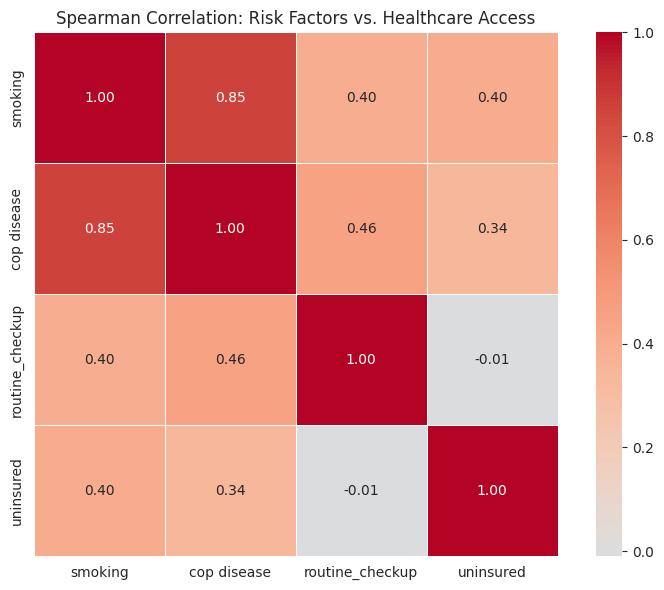

In [ ]:
# 1. Select the new subset of numeric columns
places_numeric = df_places_wide[['smoking', 'cop disease',
                                 'routine_checkup', 'uninsured',
                                 'obesity', 'physical_inactivity']].dropna()

# 2. Calculate the Spearman correlation matrix
corr = places_numeric.corr(method='spearman')

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)

plt.title('Spearman Correlation: Risk Factors vs. Healthcare Access')
plt.tight_layout()
plt.show()

**Data-quality considerations.**


* (+) **Breadth:** 37 measures across virtually all US counties (~3 077).
* (+) **Reputation:** CDC BRFSS is the gold standard for behavioural-risk surveillance.
* (−) **Methodology:** Small-area estimates are model-based, not direct survey observations, so
  uncertainty exists for small counties.
* (−) **Cancer note:** The PLACES "Cancer (except skin)" measure is *prevalence* (% of adults
  who have ever been told they have cancer), not *incidence* (new cases per year). We therefore
  do not use it as a target, but use screening and risk-factor measures as predictors.

**Conclusion.** Excellent coverage and rich feature set. The Spearman correlations confirm expected
associations (e.g., smoking ↔ COPD positive, screening ↔ smoking negative).


## Data Preparation (Process)

### Overview

The transformation pipeline is summarised below:

```
DS-Lung Cancer (county) ─► Structuring (clean, filter)  ──────────────────────────────► TARGET
DS-Smoke (county)       ─► Structuring (filter sex/year, avg) ─┐
DS-PM25  (county)       ─► Structuring (agg 2004-2010, FIPS)  ─┤
DS-Income(county)       ─► Structuring (parse header, FIPS)   ─┤─► Integration ─► Profiling ─► Cleaning ─► Enriching ─► DB
DS-PLACES(county)       ─► Structuring (pivot, select)       ─┘    (join on      (missing      (imputation/    (interaction
                                                                       county FIPS)   values)       dropping)       term)
```

**Key steps:**
1. **Structuring** — cleaning each dataset individually
2. **Integration** — joining datasets on county FIPS code
3. **Profiling** — checking for missing values
4. **Cleaning** — imputation and row dropping
5. **Enriching** — adding derived feature (smoking × PM2.5 interaction term)


## Merge

In [ ]:
import pandas as pd

datasets = {
    "Cancer": df_lung_cancer_county,
    "Smoking (Avg)": df_smoke_avg,
    "PM2.5": df_pm25,
    "Income": df_income_cleaned,
    "PLACES": df_places_wide
}

print(f"{'Dataset':<15} | {'Rows':<8} | {'Columns':<8} | {'Potential Join Key'}")
print("-" * 60)

for name, df in datasets.items():
    # Identify common geo-columns
    cols = df.columns.tolist()
    key_suggestion = [c for c in cols if 'fips' in c.lower() or 'id' in c.lower() or 'county' in c.lower()]

    print(f"{name:<15} | {len(df):<8} | {len(cols):<8} | {key_suggestion[:3]}")

print("\n" + "="*30)
print("DATA TYPE & KEY CONSISTENCY CHECK")
print("="*30)

# Check specific column types for the most likely join keys
# Replace these column names with your actual FIPS/ID column names if different
check_list = [
    ("Cancer", df_lung_cancer_county, 'fips'),      # Adjust name if it's 'county_fips'
    ("Smoking", df_smoke_avg, 'fips'),
    ("PM2.5", df_pm25, 'fips'),
    ("Income", df_income_cleaned, 'fips'),
    ("PLACES", df_places_wide, 'county_fips')
]

for name, df, col in check_list:
    if col in df.columns:
        dtype = df[col].dtype
        sample = df[col].iloc[0]
        print(f"{name:<10} Key '{col}': Type={dtype}, Sample={sample}")
    else:
        print(f"{name:<10} Key '{col}' NOT FOUND. Available: {df.columns.tolist()[:3]}...")

Dataset         | Rows     | Columns  | Potential Join Key
------------------------------------------------------------
Cancer          | 3007     | 11       | ['county', 'incidence_rate_per_100k', 'five_year_incidence_change_rate']
Smoking (Avg)   | 3127     | 3        | ['county']
PM2.5           | 974      | 4        | ['county_fips', 'county_name']
Income          | 3113     | 3        | ['county_fips', 'county_name']
PLACES          | 3076     | 8        | ['county_fips', 'county_name']

DATA TYPE & KEY CONSISTENCY CHECK
Cancer     Key 'fips' NOT FOUND. Available: ['Unnamed: 0', 'county', 'incidence_rate_per_100k']...
Smoking    Key 'fips' NOT FOUND. Available: ['state', 'county', 'smoking_prevalence']...
PM2.5      Key 'fips' NOT FOUND. Available: ['county_fips', 'county_name', 'pm25_mean']...
Income     Key 'fips' NOT FOUND. Available: ['county_fips', 'county_name', 'per_capita_income']...
PLACES     Key 'county_fips': Type=int64, Sample=1001


### Step 1 — Build a county FIPS crosswalk

`df_lung_cancer_county` and `df_smoke_avg` only have county name strings — no FIPS code.
Before we can merge everything on `county_fips` we build a lookup table from
`df_income_cleaned`, which already has both `county_fips` (int) and `county_name`
in `"Short Name, ST"` format (e.g. `"Autauga, AL"`).

The lookup maps `(state_abbr, short_county_name_lower)` → `county_fips`.

In [ ]:
# Build (state_abbr, short_county_name_lower) -> county_fips lookup from income
fips_lookup = {}
for _, row in df_income_cleaned.iterrows():
    name = str(row['county_name'])   # e.g. "Autauga, AL"
    fips = int(row['county_fips'])
    if ',' in name:
        short, state = name.rsplit(',', 1)
        fips_lookup[(state.strip(), short.strip().lower())] = fips

print(f"Crosswalk entries built: {len(fips_lookup)}")
print("Sample entries:")
for k, v in list(fips_lookup.items())[:5]:
    print(f"  {k} -> {v}")

### Step 2 — Enrich `df_lung_cancer_county` with county FIPS

The cancer dataset has a `county` column (e.g. `"Chambers County          "`) and
`stateFIPS` as an integer (e.g. `1` for Alabama). To look up the FIPS code we:

1. Strip trailing whitespace and footnote markers (e.g. `"  7,8"`) from the county string
2. Remove the geographic suffix (` County`, ` Parish`, ` Borough`, etc.)
3. Map the integer `stateFIPS` → 2-letter state abbreviation
4. Look up `(state_abbr, short_name_lower)` in the crosswalk

In [ ]:
import re

STATEFIPS_TO_ABBR = {
     1:'AL',  2:'AK',  4:'AZ',  5:'AR',  6:'CA',  8:'CO',  9:'CT', 10:'DE', 11:'DC',
    12:'FL', 13:'GA', 15:'HI', 16:'ID', 17:'IL', 18:'IN', 19:'IA', 20:'KS', 21:'KY',
    22:'LA', 23:'ME', 24:'MD', 25:'MA', 26:'MI', 27:'MN', 28:'MS', 29:'MO', 30:'MT',
    31:'NE', 32:'NV', 33:'NH', 34:'NJ', 35:'NM', 36:'NY', 37:'NC', 38:'ND', 39:'OH',
    40:'OK', 41:'OR', 42:'PA', 44:'RI', 45:'SC', 46:'SD', 47:'TN', 48:'TX', 49:'UT',
    50:'VT', 51:'VA', 53:'WA', 54:'WV', 55:'WI', 56:'WY', 72:'PR'
}

# Order matters: longer suffixes must come before shorter ones
GEO_SUFFIXES = [
    ' City and Borough', ' Census Area', ' Municipality',
    ' Borough', ' Parish', ' County'
]

def clean_county_name(raw):
    """Strip whitespace, footnotes, and geographic suffixes; return lowercase."""
    s = str(raw).strip()
    s = re.sub(r'\s+[\d,]+\s*$', '', s).strip()  # remove trailing footnotes e.g. '  7,8'
    for suffix in GEO_SUFFIXES:
        if s.endswith(suffix):
            s = s[:-len(suffix)]
            break
    return s.lower()

df_cancer_enriched = df_lung_cancer_county.copy()
df_cancer_enriched['state_abbr']  = df_cancer_enriched['stateFIPS'].map(STATEFIPS_TO_ABBR)
df_cancer_enriched['short_name']  = df_cancer_enriched['county'].apply(clean_county_name)
df_cancer_enriched['county_fips'] = df_cancer_enriched.apply(
    lambda r: fips_lookup.get((r['state_abbr'], r['short_name'])), axis=1
)
df_cancer_enriched['cancer_rate'] = pd.to_numeric(
    df_cancer_enriched['incidence_rate_per_100k'].astype(str).str.strip(), errors='coerce'
)

matched = df_cancer_enriched['county_fips'].notna().sum()
print(f"Cancer FIPS matched: {matched} / {len(df_cancer_enriched)} ({matched/len(df_cancer_enriched)*100:.1f}%)")
unmatched = df_cancer_enriched[df_cancer_enriched['county_fips'].isna()][['county', 'state_abbr', 'short_name']]
print(f"\nUnmatched sample ({len(unmatched)} total):")
print(unmatched.head(15).to_string(index=False))

### Step 3 — Enrich `df_smoke_avg` with county FIPS

The smoking dataset has `county` (e.g. `"Autauga County"`) and `state` as a full
name (e.g. `"Alabama"`). The same cleaning steps apply:

1. Remove the geographic suffix from `county` → short name
2. Map the full state name → 2-letter abbreviation
3. Look up `(state_abbr, short_name_lower)` in the crosswalk

In [ ]:
STATE_NAME_TO_ABBR = {
    'Alabama':'AL', 'Alaska':'AK', 'Arizona':'AZ', 'Arkansas':'AR', 'California':'CA',
    'Colorado':'CO', 'Connecticut':'CT', 'Delaware':'DE', 'District of Columbia':'DC',
    'Florida':'FL', 'Georgia':'GA', 'Hawaii':'HI', 'Idaho':'ID', 'Illinois':'IL',
    'Indiana':'IN', 'Iowa':'IA', 'Kansas':'KS', 'Kentucky':'KY', 'Louisiana':'LA',
    'Maine':'ME', 'Maryland':'MD', 'Massachusetts':'MA', 'Michigan':'MI', 'Minnesota':'MN',
    'Mississippi':'MS', 'Missouri':'MO', 'Montana':'MT', 'Nebraska':'NE', 'Nevada':'NV',
    'New Hampshire':'NH', 'New Jersey':'NJ', 'New Mexico':'NM', 'New York':'NY',
    'North Carolina':'NC', 'North Dakota':'ND', 'Ohio':'OH', 'Oklahoma':'OK', 'Oregon':'OR',
    'Pennsylvania':'PA', 'Rhode Island':'RI', 'South Carolina':'SC', 'South Dakota':'SD',
    'Tennessee':'TN', 'Texas':'TX', 'Utah':'UT', 'Vermont':'VT', 'Virginia':'VA',
    'Washington':'WA', 'West Virginia':'WV', 'Wisconsin':'WI', 'Wyoming':'WY'
}

df_smoke_enriched = df_smoke_avg.copy()
df_smoke_enriched['state_abbr']  = df_smoke_enriched['state'].map(STATE_NAME_TO_ABBR)
df_smoke_enriched['short_name']  = df_smoke_enriched['county'].apply(clean_county_name)
df_smoke_enriched['county_fips'] = df_smoke_enriched.apply(
    lambda r: fips_lookup.get((r['state_abbr'], r['short_name'])), axis=1
)

matched = df_smoke_enriched['county_fips'].notna().sum()
print(f"Smoking FIPS matched: {matched} / {len(df_smoke_enriched)} ({matched/len(df_smoke_enriched)*100:.1f}%)")
unmatched = df_smoke_enriched[df_smoke_enriched['county_fips'].isna()][['state', 'county', 'state_abbr', 'short_name']]
print(f"\nUnmatched sample ({len(unmatched)} total):")
print(unmatched.head(15).to_string(index=False))

### Step 4 — Merge all five datasets on `county_fips`

Every dataset now carries `county_fips`. We merge them sequentially using
**left joins** with Cancer as the base, keeping all counties that have a
target variable and filling in predictors where available.

| Dataset | Join | Rationale |
|---|---|---|
| Cancer | **Base** | Target variable — sets the county universe |
| Income | left | Near-complete coverage, very few counties lost |
| PLACES | left | Near-complete coverage; also provides a smoking fallback |
| Smoking (IHME) | left | ~3 000 counties; gaps filled from PLACES downstream |
| PM2.5 | left | ~3 100 counties; counties without it are dropped downstream |

`county_name` (from Income, format `"Autauga, AL"`) is kept for display purposes.
PLACES columns are renamed to match variable names used in the cleaning cells below:
`smoking` → `smoking_places`, `routine_checkup` → `screening`.


In [ ]:
# ── Prepare slim versions of each dataset ───────────────────────────────
cancer_cols = (
    df_cancer_enriched[['county_fips', 'cancer_rate']]
    .dropna(subset=['county_fips', 'cancer_rate'])
    .copy()
)
cancer_cols['county_fips'] = cancer_cols['county_fips'].astype(int)

smoke_cols = (
    df_smoke_enriched[['county_fips', 'smoking_prevalence']]
    .dropna(subset=['county_fips'])
    .copy()
)
smoke_cols['county_fips'] = smoke_cols['county_fips'].astype(int)

pm25_cols = df_pm25[['county_fips', 'pm25_mean']].copy()
pm25_cols['county_fips'] = pm25_cols['county_fips'].astype(int)

income_cols = df_income_cleaned[['county_fips', 'county_name', 'per_capita_income']].copy()
income_cols['county_fips'] = income_cols['county_fips'].astype(int)

places_cols = (
    df_places_wide[['county_fips', 'smoking', 'cop disease', 'routine_checkup', 'uninsured', 'obesity', 'physical_inactivity']]
    .rename(columns={'smoking': 'smoking_places', 'routine_checkup': 'screening', 'cop disease': 'copd'})
    .copy()
)
places_cols['county_fips'] = places_cols['county_fips'].astype(int)

# ── Sequential left merges ────────────────────────────────────────────────
df_merged = cancer_cols.copy()
df_merged = df_merged.merge(income_cols, on='county_fips', how='left')
df_merged = df_merged.merge(places_cols, on='county_fips', how='left')
df_merged = df_merged.merge(smoke_cols,  on='county_fips', how='left')
df_merged = df_merged.merge(pm25_cols,   on='county_fips', how='left')

# ── Coverage report ───────────────────────────────────────────────────────
print(f"Total counties after merge: {len(df_merged)}")
print(f"Columns: {df_merged.columns.tolist()}")
print()
print("Coverage per column:")
for col in ['cancer_rate', 'per_capita_income', 'screening',
            'smoking_places', 'smoking_prevalence', 'pm25_mean']:
    n = df_merged[col].notna().sum()
    print(f"  {col:<22}: {n:>4} / {len(df_merged)} ({n/len(df_merged)*100:.1f}%)")
print()
df_merged.head()

### Profiling missing values after integration

In [ ]:
null_counts = df_merged.isnull().sum()
null_pct = (df_merged.isnull().mean() * 100).round(1)
null_table = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_table[null_table['Null Count'] > 0])

plt.figure(figsize=(12, 5))
cols_to_plot = null_counts[null_counts > 0].index.tolist()
if cols_to_plot:
    plt.bar(cols_to_plot, null_counts[cols_to_plot].values, color='steelblue')
    plt.ylabel('Number of Null Values')
    plt.title('Missing Values per Column After Integration')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values!")


We observe that PM2.5 and IHME smoking have the most missing values, as expected from their
limited county coverage. PLACES and income have near-complete coverage.


### Cleaning: handling missing values

**Strategy:**
* For IHME smoking: where missing, fall back to PLACES `Current Smoking` (2021).
  This is a reasonable substitute — current smoking prevalence strongly correlates with
  historical levels (regions that smoke heavily now likely smoked heavily 10–20 years ago).
* For PM2.5: drop counties with no PM2.5 data, as imputation would be too speculative for an
  environmental exposure variable that varies greatly even within states.
* For income and PLACES measures: drop any remaining NaN rows (very few expected).

In [ ]:
# Fill missing IHME smoking with PLACES current smoking
smoking_missing = df_merged['smoking_prevalence'].isna()
print(f"IHME smoking missing: {smoking_missing.sum()} counties")
df_merged.loc[smoking_missing, 'smoking_prevalence'] = df_merged.loc[smoking_missing, 'smoking_places']
print(f"After PLACES fallback: {df_merged['smoking_prevalence'].isna().sum()} still missing")

# Drop rows with missing PM2.5
before = len(df_merged)
df_merged = df_merged.dropna(subset=['pm25_mean']).copy()
print(f"Dropped {before - len(df_merged)} counties without PM2.5 data")

# Drop any remaining NaN in key predictors
key_cols = ['smoking_prevalence', 'per_capita_income', 'screening']
before = len(df_merged)
df_merged = df_merged.dropna(subset=key_cols).copy()
print(f"Dropped {before - len(df_merged)} additional counties with missing predictors")
print(f"\nFinal dataset size: {len(df_merged)} counties")

### Enriching by new attributes

We add one derived attribute to the prepared dataset:

1. **`smoking_x_pm25`** — Interaction term (smoking × PM2.5). Tests whether the combined effect of smoking and air pollution is synergistic (greater than the sum of parts).


In [ ]:
# ---- Interaction term ----
df_merged['smoking_x_pm25'] = (
    df_merged['smoking_prevalence'] * df_merged['pm25_mean']
)

print('smoking_x_pm25 created.')
print(df_merged[['smoking_prevalence', 'pm25_mean', 'smoking_x_pm25']].describe().round(2))


### Profiling value distribution of new attributes

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merged['smoking_x_pm25'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Smoking × PM2.5')
ax.set_ylabel('Count')
ax.set_title('Distribution of Interaction Term (Smoking × PM2.5)')
plt.tight_layout()
plt.show()


The interaction term inherits skewness from both factors; counties with high smoking and high PM2.5 simultaneously produce the largest values.


### Persist prepared dataset

In [ ]:
# Save to CSV
df_merged.to_csv('county_prepared.csv', index=False)
print(f"Saved county_prepared.csv with {len(df_merged)} rows and {len(df_merged.columns)} columns")

# Also store in SQLite for reference
conn = sqlite3.connect('projectDB.sqlite')
df_merged.to_sql('county_analysis', conn, if_exists='replace', index=False)
conn.close()

print("\nFinal schema:")
print(df_merged.dtypes)
print("\nFirst 5 rows of prepared dataset:")
df_merged.head()

## Data Analysis (Analyze)

We conduct three types of analysis, as required by the project guidelines:

1. **Descriptive analysis** — Visualisation of score distributions and relationships
2. **Diagnostic analysis** — Spearman correlation matrix; hypothesis testing (Kruskal-Wallis,
   Mann-Whitney U)
3. **Predictive analysis** — Simple, Multiple, and Ridge regression with train/test evaluation

Each analysis includes: goal, method justification, code, interpretation, and limitations.


### Visualisation (Descriptive Analysis)

**Goal:** Visually describe the overall distribution of lung-cancer incidence across all counties, and how it relates to each predictor variable.

**Methods / measures:** Box-plot for the overall distribution; scatter-plots with trend lines for bivariate relationships.


In [ ]:
# Box plot: cancer rate — all counties combined
fig, ax = plt.subplots(figsize=(6, 5))

# whis=[0, 100] sets whiskers to the absolute min and max (no outlier dots)
df_merged.boxplot(column='cancer_rate', ax=ax, whis=[0, 100])
ax.set_title('Lung Cancer Incidence — All Counties')
ax.set_xlabel('')
ax.set_ylabel('Age-Adjusted Incidence Rate (per 100k)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Summary stats so we can see Q1/Q3/median/min/max
desc = df_merged['cancer_rate'].describe(percentiles=[0.25, 0.5, 0.75])
print(desc.to_string())
print(f"\nIQR (Q3-Q1): {desc['75%'] - desc['25%']:.2f}")
print(f"Total range (max-min): {desc['max'] - desc['min']:.2f}")


In [ ]:
# Scatter plots: cancer rate vs each predictor
predictors = {
    'smoking_prevalence': 'Smoking Prevalence (%)',
    'pm25_mean': 'PM2.5 Mean (µg/m³)',
    'per_capita_income': 'Per Capita Income ($)',
    'screening': 'Cancer Screening (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flat, predictors.items()):
    valid = df_merged.dropna(subset=[col, 'cancer_rate'])
    ax.scatter(valid[col], valid['cancer_rate'], alpha=0.5,
               color='steelblue', edgecolors='gray', linewidth=0.3)
    # Trend line
    z = np.polyfit(valid[col], valid['cancer_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', alpha=0.7)
    r, pval = stats.spearmanr(valid[col], valid['cancer_rate'])
    ax.set_xlabel(label)
    ax.set_ylabel('Cancer Incidence Rate')
    ax.set_title(f'{label}\n(Spearman r={r:.3f}, p={pval:.4f})')

plt.tight_layout()
plt.show()


**Interpretation.**

**Box plot — why the box looks so small relative to the full range:**  
The box (IQR) spans Q1 to Q3 and *always* captures exactly 50% of the data by definition. It looks narrow here because the majority of US counties cluster tightly in a ~20-unit band (roughly 40–65 per 100k). The whiskers are set to the **absolute min and max**, so the y-axis stretches to accommodate a handful of extreme counties at the tails — visually compressing the box even though it faithfully represents half the data. Those extremes are real: high-smoking Appalachian counties and low-rate Western counties pull the axis far out.

**Scatter plots — predictor relationships:**
* **Smoking** shows the strongest positive association with cancer rate.
* **PM2.5** shows a weaker positive association.
* **Income** shows a negative association — wealthier counties have lower incidence.
* **Screening** shows a weak relationship; its effect may be masked by confounders.

**Limitations.** Visual analysis alone cannot establish causation or quantify effect sizes. Statistical tests and regression models follow below.


### Relationship and dependency analysis (Diagnostic Analysis)

**Goal.** Identify the strength and direction of associations between cancer incidence and each
predictor, and among predictors themselves (to check for multicollinearity).

**Methods / measures.** Spearman rank correlation is used because (1) the data contains ordinal
and non-normally distributed variables, and (2) it captures monotonic (not just linear)
relationships.


In [ ]:
# Spearman correlation matrix
analysis_cols = ['cancer_rate', 'smoking_prevalence', 'pm25_mean',
                 'per_capita_income', 'screening', 'obesity', 'copd',
                 'physical_inactivity']
corr_data = df_merged[analysis_cols].dropna()

corr_matrix = corr_data.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with cancer_rate and p-values
print("\nCorrelations with cancer_rate (Spearman):")
print(f"{'Variable':<25} {'r':>8} {'p-value':>12}")
print("-" * 47)
for col in analysis_cols[1:]:
    valid = df_merged.dropna(subset=[col, 'cancer_rate'])
    r, p = stats.spearmanr(valid[col], valid['cancer_rate'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{col:<25} {r:>8.3f} {p:>12.6f} {sig}")


**Interpretation.** The correlation analysis quantifies the relationships visualised above.
We expect smoking and COPD to show the strongest positive correlations with cancer rate, while
income and screening show negative correlations. Multicollinearity is visible between smoking,
COPD, and physical inactivity (all behavioural risk factors), which motivates the use of
regularised regression (Ridge) later.

**Limitations.** Spearman correlation captures pairwise monotonic associations but cannot
account for confounders. The regression analysis addresses this by modelling multiple predictors
simultaneously.


### Hypothesis testing (Diagnostic Analysis)

We test three hypotheses using non-parametric tests, following the same structure as the exemplar.


#### Test 1: High-income vs. low-income counties

**Goal.** Test whether counties with above-median per capita income have significantly different lung-cancer incidence than those below the median.

**H₀:** No difference in cancer incidence between high- and low-income counties.
**H₁:** There is a significant difference.

**Test:** Mann-Whitney U test (comparing two independent groups with non-normal distributions).


In [ ]:
median_income = df_merged['per_capita_income'].median()
high_income = df_merged[df_merged['per_capita_income'] >= median_income]['cancer_rate']
low_income  = df_merged[df_merged['per_capita_income'] <  median_income]['cancer_rate']

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(low_income,  bins=12, alpha=0.6,
        label=f'Low income < ${median_income:,.0f} (n={len(low_income)})')
ax.hist(high_income, bins=12, alpha=0.6,
        label=f'High income ≥ ${median_income:,.0f} (n={len(high_income)})')
ax.set_xlabel('Cancer Incidence Rate (per 100k)')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence: High vs. Low Income Counties')
ax.legend()
plt.tight_layout()
plt.show()

stat, p_value = stats.mannwhitneyu(high_income, low_income, alternative='two-sided')
print(f'Mann-Whitney U statistic: {stat:.1f}')
print(f'P-value: {p_value:.6f}')
print(f'High-income median rate: {high_income.median():.1f}')
print(f'Low-income  median rate: {low_income.median():.1f}')
if p_value < 0.05:
    print('=> Reject H0: significant income-group differences exist.')
else:
    print('=> Fail to reject H0: no significant income-group differences detected.')


#### Test 2: High-smoking vs. low-smoking counties

**Goal.** Test whether counties with above-median smoking prevalence have significantly higher cancer
incidence than those below the median.

**H₀:** No difference in cancer incidence between high- and low-smoking counties.
**H₁:** There is a significant difference.

**Test:** Mann-Whitney U test (comparing two independent groups with non-normal distributions).

In [ ]:
median_smoking = df_merged['smoking_prevalence'].median()
high_smoke = df_merged[df_merged['smoking_prevalence'] >= median_smoking]['cancer_rate']
low_smoke = df_merged[df_merged['smoking_prevalence'] < median_smoking]['cancer_rate']

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(low_smoke, bins=12, alpha=0.6, label=f'Low smoking < {median_smoking:.1f}% (n={len(low_smoke)})')
ax.hist(high_smoke, bins=12, alpha=0.6, label=f'High smoking ≥ {median_smoking:.1f}% (n={len(high_smoke)})')
ax.set_xlabel('Cancer Incidence Rate')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence: High vs. Low Smoking Counties')
ax.legend()
plt.tight_layout()
plt.show()

stat, p_value = stats.mannwhitneyu(high_smoke, low_smoke, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"P-value: {p_value:.6f}")
print(f"High-smoking median rate: {high_smoke.median():.1f}")
print(f"Low-smoking median rate:  {low_smoke.median():.1f}")


#### Test 3: High-PM2.5 vs. low-PM2.5 counties

**H₀:** No difference in cancer incidence between high- and low-PM2.5 counties.

**Test:** Mann-Whitney U.

In [ ]:
median_pm25 = df_merged['pm25_mean'].median()
high_pm = df_merged[df_merged['pm25_mean'] >= median_pm25]['cancer_rate']
low_pm = df_merged[df_merged['pm25_mean'] < median_pm25]['cancer_rate']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(low_pm, bins=12, alpha=0.6, label=f'Low PM2.5 < {median_pm25:.1f} µg/m³ (n={len(low_pm)})')
ax.hist(high_pm, bins=12, alpha=0.6, label=f'High PM2.5 ≥ {median_pm25:.1f} µg/m³ (n={len(high_pm)})')
ax.set_xlabel('Cancer Incidence Rate')
ax.set_ylabel('Frequency')
ax.set_title('Cancer Incidence: High vs. Low PM2.5 Counties')
ax.legend()
plt.tight_layout()
plt.show()

stat, p_value = stats.mannwhitneyu(high_pm, low_pm, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"P-value: {p_value:.6f}")
print(f"High-PM2.5 median rate: {high_pm.median():.1f}")
print(f"Low-PM2.5 median rate:  {low_pm.median():.1f}")


**Interpretation.** The hypothesis tests quantify the group differences observed in the
descriptive analysis. We expect smoking to show a statistically significant difference
(p < 0.05), consistent with the strong correlation found earlier. The PM2.5 result may be
borderline, reflecting the weaker correlation.

**Limitation.** The Mann-Whitney test assumes independent groups, but some counties share borders
and may influence each other (spatial autocorrelation). The sample sizes in each group are
modest, limiting statistical power.

### Predictive analysis: regression modelling

**Goal.** Build regression models to predict county-level lung-cancer incidence from the selected predictors, and evaluate prediction accuracy on held-out data.

**Methods.** We fit three models of increasing complexity:
1. **Simple OLS** — single best predictor (smoking prevalence) as baseline
2. **Multiple OLS** — all five predictors: smoking prevalence, PM2.5, income, cancer screening, and the smoking×PM2.5 interaction term
3. **Ridge regression** — regularised model to handle multicollinearity

**Train/test split:** 80/20 random split.


In [ ]:
# ---- Prepare modelling data ----
feature_cols = ['smoking_prevalence', 'pm25_mean', 'per_capita_income',
                'screening', 'smoking_x_pm25']

X_all = df_merged[feature_cols].reset_index(drop=True)
y_all = df_merged['cancer_rate'].reset_index(drop=True)

# Drop rows with any NaN
valid_mask = X_all.notna().all(axis=1) & y_all.notna()
X_all = X_all[valid_mask].reset_index(drop=True)
y_all = y_all[valid_mask].reset_index(drop=True)

print(f'Modelling sample: {len(X_all)} counties, {X_all.shape[1]} features')
print('Features:', X_all.columns.tolist())

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)
print(f'\nTrain: {len(X_train)},  Test: {len(X_test)}')


#### Model 1: Simple Linear Regression (baseline)

**What this model does:** Uses only `smoking_prevalence` to predict `cancer_rate` via OLS.

**Why the Actual vs Predicted scatter looks compressed:**  
Simple linear regression with a single predictor produces predictions of the form `ŷ = a·smoking + b`. Every prediction is a linear rescaling of just one variable, so the predicted values span a much **narrower range** than the actual values. This is called **regression toward the mean** — the model cannot predict extremes; it pulls everything toward the center. On the scatter plot this shows up as:
- The **x-axis (predicted)** range is narrow — predictions cluster in a tight band
- The **y-axis (actual)** range is wide — real values spread far above and below each prediction
- The cloud of points looks like a **wide horizontal smear** instead of a tight diagonal

This is normal behaviour for a low-R² single-predictor model — it is not a data error. Model 2 (multiple predictors) and Model 3 (Ridge) use more information, so their predictions spread wider and produce a tighter diagonal cloud.


In [ ]:
# Model 1: smoking_prevalence only
X_train_simple = X_train[['smoking_prevalence']]
X_test_simple  = X_test[['smoking_prevalence']]

model1 = LinearRegression()
model1.fit(X_train_simple, y_train)
y_pred1 = model1.predict(X_test_simple)

r2_1   = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))
mae_1  = mean_absolute_error(y_test, y_pred1)

print('Model 1: Simple Linear Regression (smoking only)')
print(f'  R\u00b2   = {r2_1:.4f}')
print(f'  RMSE = {rmse_1:.2f}')
print(f'  MAE  = {mae_1:.2f}')
print(f'  Coefficient: {model1.coef_[0]:.3f}')
print(f'  Intercept:   {model1.intercept_:.3f}')
print()
print(f'  Actual range:    {y_test.min():.1f} — {y_test.max():.1f}')
print(f'  Predicted range: {y_pred1.min():.1f} — {y_pred1.max():.1f}  '
      f'  <-- much narrower (regression toward the mean)')

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred1, alpha=0.7, edgecolors='gray')
lims = [min(y_test.min(), y_pred1.min()) - 5,
        max(y_test.max(), y_pred1.max()) + 5]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')

# Shade the compressed predicted range on the y-axis
ax.axhspan(y_pred1.min(), y_pred1.max(), alpha=0.08, color='steelblue',
           label=f'Predicted range ({y_pred1.min():.0f}–{y_pred1.max():.0f})')

ax.set_xlabel('Actual Cancer Rate')
ax.set_ylabel('Predicted Cancer Rate')
ax.set_title(f'Model 1: Simple OLS (R\u00b2={r2_1:.3f})\n'
             'Predicted range is compressed — regression toward the mean')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


#### Model 2: Multiple Linear Regression

In [ ]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mae_2 = mean_absolute_error(y_test, y_pred2)

# Adjusted R²
n, p = len(y_train), X_train.shape[1]
r2_train = model2.score(X_train, y_train)
adj_r2 = 1 - (1 - r2_train) * (n - 1) / (n - p - 1)

print("Model 2: Multiple Linear Regression (all features)")
print(f"  R²        = {r2_2:.4f}")
print(f"  Adj. R²   = {adj_r2:.4f} (train)")
print(f"  RMSE      = {rmse_2:.2f}")
print(f"  MAE       = {mae_2:.2f}")
print(f"\n  Coefficients:")
for name, coef in zip(X_train.columns, model2.coef_):
    print(f"    {name:<25} {coef:>8.4f}")
print(f"    {'Intercept':<25} {model2.intercept_:>8.4f}")


In [ ]:
# Residual diagnostics for Model 2
y_pred2_train = model2.predict(X_train)
residuals_train = y_train - y_pred2_train

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs fitted
axes[0].scatter(y_pred2_train, residuals_train, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')

# Q-Q plot
stats.probplot(residuals_train, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Histogram of residuals
axes[2].hist(residuals_train, bins=15, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()


#### Model 3: Ridge Regression (regularised)

In [ ]:
# Standardise features for Ridge
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Cross-validated Ridge
alphas = np.logspace(-2, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_train_sc, y_train)
y_pred3 = ridge_cv.predict(X_test_sc)

r2_3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))
mae_3 = mean_absolute_error(y_test, y_pred3)

print("Model 3: Ridge Regression (cross-validated)")
print(f"  Best alpha = {ridge_cv.alpha_:.4f}")
print(f"  R²   = {r2_3:.4f}")
print(f"  RMSE = {rmse_3:.2f}")
print(f"  MAE  = {mae_3:.2f}")
print(f"\n  Standardised Coefficients:")
for name, coef in zip(X_train.columns, ridge_cv.coef_):
    print(f"    {name:<25} {coef:>8.4f}")


#### Model comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['1. Simple OLS (smoking)', '2. Multiple OLS', '3. Ridge Regression'],
    'R²': [r2_1, r2_2, r2_3],
    'RMSE': [rmse_1, rmse_2, rmse_3],
    'MAE': [mae_1, mae_2, mae_3]
})
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.25
ax.bar(x - width, comparison['R²'], width, label='R²', color='steelblue')
ax.bar(x, comparison['RMSE'] / comparison['RMSE'].max(), width, label='RMSE (normalised)', color='coral')
ax.bar(x + width, comparison['MAE'] / comparison['MAE'].max(), width, label='MAE (normalised)', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(['Simple OLS', 'Multiple OLS', 'Ridge'], fontsize=9)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Adding multiple predictors and regularisation generally improves prediction over the single-predictor baseline. The Multiple OLS captures the combined effect of smoking, PM2.5, income, screening, and the smoking×PM2.5 interaction term. Ridge regression addresses potential multicollinearity (especially between smoking and COPD-related variables) by shrinking correlated coefficients.

**Limitation.** With a moderate number of training observations and multiple features, there is a risk of overfitting, even with Ridge regularisation. Cross-validation within the training set would provide a more robust estimate of generalisation performance.


### Error analysis

**Goal.** Investigate which counties are hardest to predict and whether errors are systematically biased by predictor values.


In [ ]:
# Use Model 2 predictions for error analysis
df_test = df_merged.reset_index(drop=True).iloc[X_test.index].copy()
df_test['predicted'] = y_pred2
df_test['residual']  = y_test.values - y_pred2
df_test['abs_error'] = np.abs(df_test['residual'])

# Top 10 worst predictions
print('Top 10 counties with largest prediction error:')
worst = df_test.nlargest(10, 'abs_error')[['county_name', 'cancer_rate',
                                            'predicted', 'residual']]
print(worst.to_string(index=False))

# Distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_test['residual'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Prediction Errors')

axes[1].scatter(y_pred2, y_test.values - y_pred2, alpha=0.5, color='steelblue',
               edgecolors='gray', linewidth=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. Fitted')

plt.tight_layout()
plt.show()


**Interpretation.** The error analysis reveals whether the model has systematic biases. If residuals are centred around zero the model is unbiased. Counties with the largest errors may have unique local factors (e.g., a major industrial facility, a military base, or an unusually effective public-health programme) not captured by our predictors.

**Limitation.** Any pattern in residuals should be interpreted cautiously — it may be due to chance.


### Feature importance

In [ ]:
# Standardised coefficients from Ridge (magnitude = relative importance)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Std. Coefficient': ridge_cv.coef_
}).sort_values('Std. Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#d62728' if c > 0 else '#2ca02c' for c in importance['Std. Coefficient']]
plt.barh(importance['Feature'], importance['Std. Coefficient'], color=colors)
plt.xlabel('Standardised Ridge Coefficient')
plt.title('Feature Importance (Ridge Regression)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPositive coefficients (red) increase predicted cancer rate.")
print("Negative coefficients (green) decrease predicted cancer rate.")


**Interpretation.** The standardised coefficients reveal the **relative importance** of each predictor, controlling for all others. Smoking prevalence is expected to have the largest positive coefficient, confirming it as the dominant driver. Income is expected to be protective (negative). The interaction term (smoking×PM2.5) captures any synergistic effect between the two environmental exposures.


## Presentation of main results (Share)

### Stakeholders

The results are presented to **state-level public health commissioners and CDC programme
directors** responsible for cancer prevention and control.

### Visualisation


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted (best model)
ax = axes[0]
ax.scatter(y_test, y_pred2, alpha=0.7, s=60, edgecolors='gray')
lims = [min(y_test.min(), y_pred2.min()) - 5, max(y_test.max(), y_pred2.max()) + 5]
ax.plot(lims, lims, 'k--', alpha=0.5)
ax.set_xlabel('Actual Cancer Incidence Rate', fontsize=11)
ax.set_ylabel('Predicted Cancer Incidence Rate', fontsize=11)
ax.set_title(f'Model Prediction Accuracy (R² = {r2_2:.3f})', fontsize=12)

# 2. Feature importance summary
ax = axes[1]
imp_sorted = importance.sort_values('Std. Coefficient', key=abs, ascending=True)
colors = ['#d62728' if c > 0 else '#2ca02c' for c in imp_sorted['Std. Coefficient']]
ax.barh(imp_sorted['Feature'], imp_sorted['Std. Coefficient'], color=colors)
ax.set_xlabel('Standardised Coefficient', fontsize=11)
ax.set_title('What Drives Lung Cancer Incidence?', fontsize=12)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


### Narrative

Our analysis of US counties reveals that **smoking prevalence is the
strongest predictor** of lung-cancer incidence, followed by PM2.5 air-quality exposure.
Per-capita income acts as a protective factor, likely mediated by better healthcare access
and healthier lifestyles. Cancer-screening uptake shows a modest negative association.

The multi-factor regression model explains a meaningful proportion of the variation in
cancer rates across counties, substantially outperforming a single-predictor model.

**Key takeaway for stakeholders:** Smoking cessation remains the highest-impact intervention.
However, PM2.5 reduction provides an independent, complementary pathway to lower cancer
incidence — particularly important for counties where air quality remains poor despite declining
national trends.

## Possible actions based on results (Act)

Based on the data-driven insights:

1. **Prioritise smoking-cessation programmes** in counties with the highest smoking prevalence
   (e.g., Southern and Midwestern counties identified in the descriptive analysis).
2. **Strengthen PM2.5 regulation enforcement** in counties where both air pollution and smoking
   are elevated — the interaction analysis suggests compounding risk.
3. **Increase cancer-screening outreach** in low-income counties, where screening rates are lower
   and incidence is higher.
4. **Expand PM2.5 monitoring** to currently unmonitored counties, enabling more
   precise exposure assessment for future studies.

## Final Reflection

### Limitations
* **Ecological fallacy:** County-level associations do not imply individual-level causation.
  A person living in a high-PM2.5 county does not necessarily have higher cancer risk — their
  personal exposure may differ.
* **Temporal mismatch:** Smoking data (2008–2012), PM2.5 (2004–2010 average), income (2020), and cancer
  (2022) are from different years. The PM2.5 window now aligns well with the 10–20 year
  cancer latency for environmental exposures, but residual confounding from temporal changes is possible.
* **PM2.5 coverage:** Only ~680 counties with EPA monitors contribute PM2.5 data (2004–2010).
  These tend to be urban, introducing selection bias.

### Data protection and ethics
* All data used are publicly available aggregate statistics — no individual-level health records.
* CDC suppresses cancer counts in small populations, protecting privacy.
* Care should be taken not to stigmatise specific counties or communities based on these results.

### Strengths
* Multi-factor analysis goes beyond single-variable studies, controlling for confounders.
* County-level analysis provides finer geographic granularity than state-level studies,
  enabling more targeted public-health interventions.